# Attack-type analysis — VAE, step by step

**Derived from:** `06_attack_type_analysis/derive_attack_type_labels.py`,
`evaluate_by_attack_type.py`, `evaluate_pairwise_attack_type.py`.

**Model:** clean-only (0% train contamination) VAE,
`phase3_vae/05_contamination_sweep/04_models/contam_0pct` (20 seeds,
threshold_95 per seed, inference only — nothing here retrains anything).

**Scoring: deterministic z_mean** (audit finding O2, `11_fable_review/`): z = z_mean at inference — no eps sample, no eval seed; threshold_95 is recomputed per seed as the 95th percentile of the deterministic error on the held-out val-benign set, matching the canonical `10_final_report` results (see `CHANGELOG.md`).

**Data:** `03_phase3_splits/test_indices.csv` (benign) + attack pool, labeled
by attack_type in `06_attack_type_analysis/test_with_attack_type.csv`,
features reconstructed via row_index against `features_all_windows.csv` +
the two resampled-window feature tables.

This notebook re-runs the actual functions from those scripts (not a
copy-paste of their logic) at reduced seed counts for the step-by-step demo
cells, and loads the scripts' full 20-seed published CSV outputs for the
final authoritative numbers, exactly as they appear in
`06_attack_type_analysis/results_*.md`.

In [1]:
import os, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc, confusion_matrix, ConfusionMatrixDisplay

PROJECT_ROOT = "/Users/mustafa/Desktop/NIDS/IDS-Project"
ATTACK_TYPE_DIR = os.path.join(PROJECT_ROOT, "06_attack_type_analysis")
REPORT_DIR = os.path.join(PROJECT_ROOT, "10_final_report")
sys.path.insert(0, ATTACK_TYPE_DIR)
sys.path.insert(0, os.path.join(PROJECT_ROOT, "analysis"))
import evaluate_by_attack_type as single
import evaluate_pairwise_attack_type as pairwise
import derive_attack_type_labels as derive

# evaluate_by_attack_type imports evaluate_contamination_sweep_extended.py (for
# reconstruction_error()), which calls matplotlib.use("Agg") as a side effect --
# re-request the inline backend here, after that import, so plots below render
# in the notebook instead of silently going nowhere.
%matplotlib inline

pd.set_option("display.width", 160)
print("Modules loaded:", single.__file__, pairwise.__file__, derive.__file__)

Modules loaded: /Users/mustafa/Desktop/NIDS/IDS-Project/06_attack_type_analysis/evaluate_by_attack_type.py /Users/mustafa/Desktop/NIDS/IDS-Project/06_attack_type_analysis/evaluate_pairwise_attack_type.py /Users/mustafa/Desktop/NIDS/IDS-Project/06_attack_type_analysis/derive_attack_type_labels.py


## 1. Attack-type label derivation

Re-runs `derive_attack_type_labels.main()`'s actual logic (its own imported `load_window_meta`/`load_attack_intervals`/`assign_attack_type_global` functions from `analysis/attack_type_separability.py`), producing the same `attack_type` column that was written once to `test_with_attack_type.csv`, so this is a live re-derivation, not a load of the static file.

In [2]:
window_meta = derive.base.load_window_meta()
intervals_by_window = derive.base.load_attack_intervals(window_meta)
flat_intervals = derive.flatten_intervals(intervals_by_window)
print(f"Pooled {len(flat_intervals)} attack command intervals across all real windows.")

test_df = pd.read_csv(derive.TEST_INDICES_PATH)
print(f"test_indices.csv: {len(test_df)} rows, {int(test_df['is_attack'].sum())} attack flows")

attack_type = pd.Series("benign", index=test_df.index, dtype=object)
attack_mask = test_df["is_attack"] == 1
attack_type.loc[attack_mask] = test_df.loc[attack_mask, "ts"].apply(
    lambda ts: derive.assign_attack_type_global(ts, flat_intervals)
)
attack_type = attack_type.replace({"portscan_test": "portscan"})
test_df["attack_type"] = attack_type

n_attack = int(attack_mask.sum())
n_unmatched = int((test_df.loc[attack_mask, "attack_type"] == "unmatched").sum())
print(f"Match rate: {1 - n_unmatched/n_attack:.2%} ({n_attack - n_unmatched}/{n_attack} attack flows labeled)")
test_df.loc[attack_mask, "attack_type"].value_counts()

Pooled 42 attack command intervals across all real windows.
test_indices.csv: 9931 rows, 3110 attack flows
Match rate: 100.00% (3110/3110 attack flows labeled)


attack_type
apache_bench    1487
slowloris        929
portscan         694
Name: count, dtype: int64

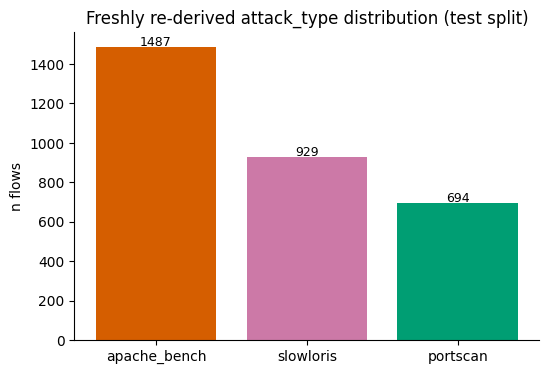

In [3]:
counts = test_df.loc[attack_mask, "attack_type"].value_counts()
fig, ax = plt.subplots(figsize=(6, 4))
colors = {"apache_bench": "#D55E00", "portscan": "#009E73", "slowloris": "#CC79A7", "unmatched": "#888888"}
ax.bar(counts.index, counts.values, color=[colors.get(k, "#888888") for k in counts.index])
ax.set_ylabel("n flows")
ax.set_title("Freshly re-derived attack_type distribution (test split)")
for i, v in enumerate(counts.values):
    ax.text(i, v + 5, str(v), ha="center", fontsize=9)
ax.spines[["top", "right"]].set_visible(False)
plt.show()

In [4]:
persisted = pd.read_csv(derive.OUT_PATH)
print("Persisted test_with_attack_type.csv:")
print("shape:", persisted.shape)
display(persisted.head())
match = (persisted["attack_type"].values == test_df["attack_type"].values).all()
print("Freshly re-derived attack_type matches the persisted file exactly:", match)

Persisted test_with_attack_type.csv:
shape: (9931, 6)


,row_index,window_id,is_attack,signature_id,ts,attack_type
0,549,window_02_3pct,0,412,1.783696e+09,benign
1,555,window_02_3pct,0,416,1.783696e+09,benign
2,556,window_02_3pct,0,417,1.783696e+09,benign
3,557,window_02_3pct,0,416,1.783696e+09,benign
4,561,window_02_3pct,0,421,1.783696e+09,benign


Freshly re-derived attack_type matches the persisted file exactly: True


## 2. Single attack-type VAE evaluation

One cell per attack type. Uses a **5-seed demo backend** (`single.VAEBackend(seeds=[0..4], deterministic=True)`) against the same model directory as the published 20-seed run, so the ROC curve / confusion matrix below are real model output — scored deterministically with z = z_mean, per-seed threshold_95 recalibrated on val-benign — just averaged over fewer seeds for notebook speed. The full 20-seed numbers are loaded from the canonical deterministic table `10_final_report/01_single_attack_type/vae/results.csv` afterwards for the authoritative table.

In [5]:
feature_cols = single.load_feature_cols()
df = single.assemble_labeled_features_df(feature_cols)
display(df.head())
print("shape:", df.shape)
demo_backend = single.VAEBackend(seeds=list(range(5)), deterministic=True)
print("Demo backend seeds:", demo_backend.seeds)

Loading test_with_attack_type.csv (row_index/window_id/is_attack/attack_type)...
Reconstructing feature columns via row_index against the combined features_all_windows.csv + resampled-window feature tables...


Assembled eval frame: 9931 rows, 18 feature columns.


,row_index,window_id,is_attack,signature_id,ts,attack_type,duration_scaled,orig_bytes_scaled,resp_bytes_scaled,orig_pkts_scaled,...,proto_tcp,proto_udp,service_dns,service_http,service_none,service_ssh,conn_state_REJ,conn_state_RSTO,conn_state_S1,conn_state_SF
0,549,window_02_3pct,0,412,1.783696e+09,benign,0.324309,0.384574,1.619641,0.683299,...,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
1,555,window_02_3pct,0,416,1.783696e+09,benign,-0.118274,-0.003069,-0.167400,-0.036949,...,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
2,556,window_02_3pct,0,417,1.783696e+09,benign,0.177133,0.360372,-0.034158,0.050887,...,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
3,557,window_02_3pct,0,416,1.783696e+09,benign,-0.118255,-0.004113,1.369642,0.472495,...,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
4,561,window_02_3pct,0,421,1.783696e+09,benign,-0.389623,-0.369849,-0.737906,-0.405856,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0


shape: (9931, 24)
Demo backend seeds: [0, 1, 2, 3, 4]


  [VAEBackend] val-benign reference set for deterministic threshold_95: 653 flows


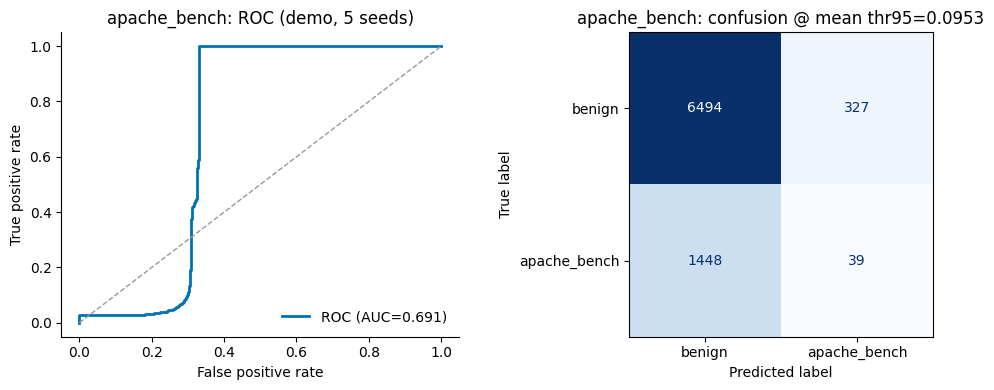

n_benign=6821 n_attack=1487 demo ROC-AUC=0.6913 demo recall@thr95=0.0262 demo benign_FPR@thr95=0.0479


In [6]:
def demo_single_attack_type(attack_type, backend):
    subset = df[(df["is_attack"] == 0) | (df["attack_type"] == attack_type)].copy()
    X = subset[feature_cols].values.astype("float32")
    y = subset["is_attack"].values
    error_matrix, thresholds = single.compute_error_matrix(X, backend=backend)
    mean_error = error_matrix.mean(axis=0)
    mean_thr = float(np.mean(thresholds))
    fpr, tpr, _ = roc_curve(y, mean_error)
    roc_auc = auc(fpr, tpr)
    pred = (mean_error > mean_thr).astype(int)
    cm = confusion_matrix(y, pred)

    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    axes[0].plot(fpr, tpr, color="#0072B2", linewidth=2, label=f"ROC (AUC={roc_auc:.3f})")
    axes[0].plot([0, 1], [0, 1], color="#999999", linestyle="--", linewidth=1)
    axes[0].set_xlabel("False positive rate"); axes[0].set_ylabel("True positive rate")
    axes[0].set_title(f"{attack_type}: ROC (demo, {len(backend.seeds)} seeds)")
    axes[0].legend(frameon=False); axes[0].spines[["top", "right"]].set_visible(False)

    ConfusionMatrixDisplay(cm, display_labels=["benign", attack_type]).plot(ax=axes[1], colorbar=False, cmap="Blues")
    axes[1].set_title(f"{attack_type}: confusion @ mean thr95={mean_thr:.4f}")
    fig.tight_layout()
    plt.show()
    print(f"n_benign={int((y==0).sum())} n_attack={int((y==1).sum())} demo ROC-AUC={roc_auc:.4f} "
          f"demo recall@thr95={pred[y==1].mean():.4f} demo benign_FPR@thr95={pred[y==0].mean():.4f}")

demo_single_attack_type("apache_bench", demo_backend)

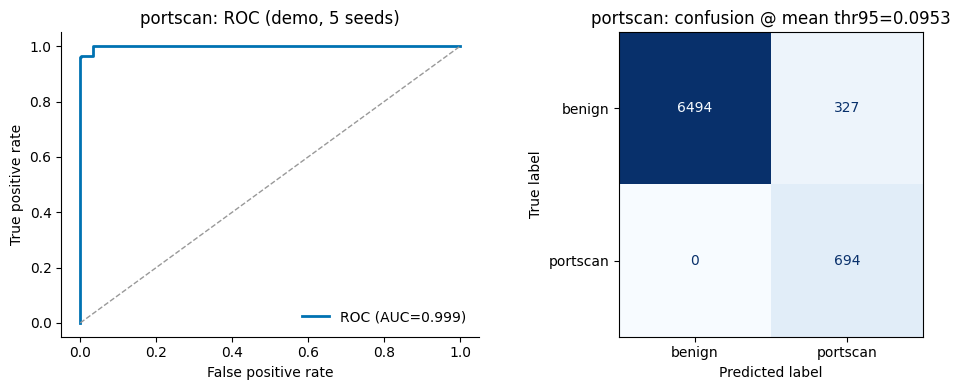

n_benign=6821 n_attack=694 demo ROC-AUC=0.9988 demo recall@thr95=1.0000 demo benign_FPR@thr95=0.0479


In [7]:
demo_single_attack_type("portscan", demo_backend)

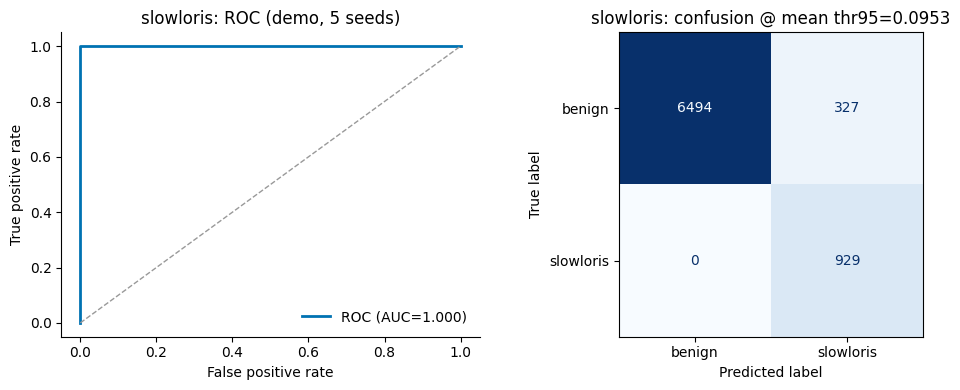

n_benign=6821 n_attack=929 demo ROC-AUC=1.0000 demo recall@thr95=1.0000 demo benign_FPR@thr95=0.0479


In [8]:
demo_single_attack_type("slowloris", demo_backend)

### Published (20-seed) single attack-type results

Loaded directly from the canonical deterministic table `10_final_report/01_single_attack_type/vae/results.csv` (z_mean scoring; hybrid metrics — PR-AUC/F1 from the dedup set, recall/ROC-AUC/benign-FPR from the full set, see `10_final_report/CHANGELOG.md`) — the authoritative numbers behind the demo runs above.

,attack_type,n_benign,n_attack,pr_auc_mean,pr_auc_std,roc_auc_mean,roc_auc_std,f1_mean,f1_std,benign_fpr_mean,benign_fpr_std,attack_recall_mean,attack_recall_std,n_benign_dedup,n_attack_dedup
0,apache_bench,6821,1487,0.224375,3.486904e-02,0.666955,8.896858e-02,0.040983,0.001055,0.057726,0.005773,0.026227,0.000000,5428,968
1,portscan,6821,694,0.992137,2.348506e-03,0.998782,4.877575e-04,0.768925,0.019502,0.057726,0.005773,0.998271,0.007733,5428,539
2,slowloris,6821,929,1.000000,7.204078e-17,1.000000,5.695324e-17,0.798617,0.016887,0.057726,0.005773,1.000000,0.000000,5428,640


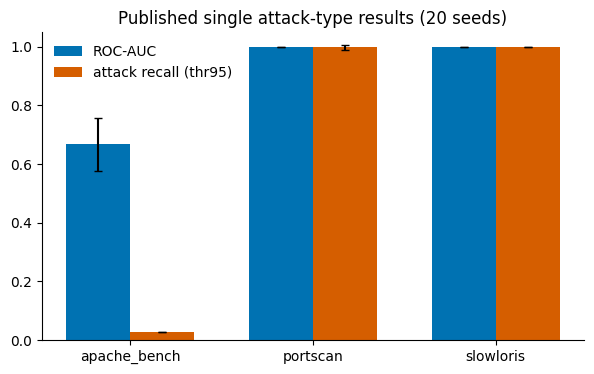

In [9]:
results_single = pd.read_csv(os.path.join(REPORT_DIR, "01_single_attack_type", "vae", "results.csv"))
display(results_single)

fig, ax = plt.subplots(figsize=(7, 4))
x = np.arange(len(results_single))
width = 0.35
ax.bar(x - width/2, results_single["roc_auc_mean"], width, yerr=results_single["roc_auc_std"],
       label="ROC-AUC", color="#0072B2", capsize=3)
ax.bar(x + width/2, results_single["attack_recall_mean"], width, yerr=results_single["attack_recall_std"],
       label="attack recall (thr95)", color="#D55E00", capsize=3)
ax.set_xticks(x); ax.set_xticklabels(results_single["attack_type"])
ax.set_ylim(0, 1.05); ax.legend(frameon=False)
ax.set_title("Published single attack-type results (20 seeds)")
ax.spines[["top", "right"]].set_visible(False)
plt.show()

## 3. Pairwise group evaluation — pooled vs. decomposed recall

`evaluate_group()` already reports both **pooled** `attack_recall` (over every attack flow in the pair's mixed evaluation set) and, per constituent type, `recall__<type>` (that type's own flows only, at the same model/threshold). Since detection is a per-flow decision, the decomposed number is expected to match that type's solo recall almost exactly — this section demonstrates that live, then shows the full 3-pair, 20-seed published comparison.

In [10]:
demo_pair_rows = []
for pair in pairwise.PAIRS:
    name = pairwise.pair_name(pair)
    subset = df[(df["is_attack"] == 0) | (df["attack_type"].isin(pair))].copy()
    demo_pair_rows.extend(single.evaluate_group(subset, feature_cols, name, backend=demo_backend))
demo_pair_df = pd.DataFrame(demo_pair_rows)
demo_pair_df.head()


=== portscan+apache_bench: n_benign=6821, n_attack=2181 ===
  mean over 5 seeds: ROC-AUC=0.7920 PR-AUC=0.5988 F1=0.4458 benign_FPR=0.0549 attack_recall=0.3361

=== portscan+slowloris: n_benign=6821, n_attack=1623 ===


  mean over 5 seeds: ROC-AUC=0.9994 PR-AUC=0.9979 F1=0.8966 benign_FPR=0.0549 attack_recall=1.0000

=== apache_bench+slowloris: n_benign=6821, n_attack=2416 ===


  mean over 5 seeds: ROC-AUC=0.8126 PR-AUC=0.6634 F1=0.5151 benign_FPR=0.0549 attack_recall=0.4007


,attack_type,seed,n_benign,n_attack,threshold_95,pr_auc,roc_auc,f1,benign_fpr,attack_recall,recall__apache_bench,recall__portscan,recall__slowloris
0,portscan+apache_bench,0,6821,2181,0.089787,0.608219,0.806560,0.442767,0.058203,0.336084,0.026227,1.0,NaN
1,portscan+apache_bench,1,6821,2181,0.084913,0.635454,0.835358,0.452469,0.047794,0.336084,0.026227,1.0,NaN
2,portscan+apache_bench,2,6821,2181,0.100894,0.578691,0.765792,0.448455,0.052045,0.336084,0.026227,1.0,NaN
3,portscan+apache_bench,3,6821,2181,0.096075,0.579658,0.766717,0.440770,0.060402,0.336084,0.026227,1.0,NaN
4,portscan+apache_bench,4,6821,2181,0.104654,0.591886,0.785569,0.444647,0.056150,0.336084,0.026227,1.0,NaN


,attack_recall,recall__apache_bench,recall__portscan,recall__slowloris
attack_type,,,,
apache_bench+slowloris,0.400662,0.026227,NaN,1.0
portscan+apache_bench,0.336084,0.026227,1.0,NaN
portscan+slowloris,1.000000,NaN,1.0,1.0



=== portscan: n_benign=6821, n_attack=694 ===


  mean over 5 seeds: ROC-AUC=0.9987 PR-AUC=0.9903 F1=0.7877 benign_FPR=0.0549 attack_recall=1.0000

=== apache_bench: n_benign=6821, n_attack=1487 ===
  mean over 5 seeds: ROC-AUC=0.6955 PR-AUC=0.2661 F1=0.0411 benign_FPR=0.0549 attack_recall=0.0262

=== slowloris: n_benign=6821, n_attack=929 ===


  mean over 5 seeds: ROC-AUC=1.0000 PR-AUC=1.0000 F1=0.8324 benign_FPR=0.0549 attack_recall=1.0000


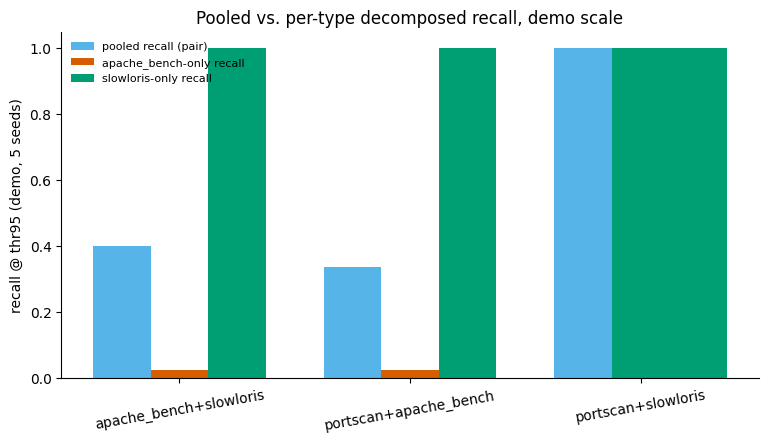

Demo solo recall (reference):
attack_type
apache_bench    0.026227
portscan        1.000000
slowloris       1.000000
Name: attack_recall, dtype: float64


In [11]:
recall_cols = [c for c in demo_pair_df.columns if c.startswith("recall__")]
demo_pair_summary = demo_pair_df.groupby("attack_type")[["attack_recall"] + recall_cols].mean()
display(demo_pair_summary)

demo_solo_rows = []
for atype in single.ATTACK_TYPES:
    subset = df[(df["is_attack"] == 0) | (df["attack_type"] == atype)].copy()
    demo_solo_rows.extend(single.evaluate_group(subset, feature_cols, atype, backend=demo_backend))
demo_solo_recall = pd.DataFrame(demo_solo_rows).groupby("attack_type")["attack_recall"].mean()

fig, ax = plt.subplots(figsize=(9, 4.5))
pairs = demo_pair_summary.index.tolist()
x = np.arange(len(pairs))
width = 0.25
ax.bar(x - width, demo_pair_summary["attack_recall"], width, label="pooled recall (pair)", color="#56B4E9")
for i, pair_name in enumerate(pairs):
    types_in_pair = [c.replace("recall__", "") for c in recall_cols if not pd.isna(demo_pair_summary.loc[pair_name, c])]
    for j, t in enumerate(types_in_pair):
        val = demo_pair_summary.loc[pair_name, f"recall__{t}"]
        ax.bar(x[i] + j*width, val, width, color="#D55E00" if t == "apache_bench" else "#009E73",
               label=f"{t}-only recall" if (i == 0) else None)
ax.set_xticks(x); ax.set_xticklabels(pairs, rotation=10)
ax.set_ylabel("recall @ thr95 (demo, 5 seeds)")
ax.set_title("Pooled vs. per-type decomposed recall, demo scale")
ax.legend(frameon=False, fontsize=8)
ax.spines[["top", "right"]].set_visible(False)
plt.show()
print("Demo solo recall (reference):"); print(demo_solo_recall)

### Published (20-seed) pairwise + combined comparison

Loaded from the canonical deterministic tables `10_final_report/02_pairwise_attack_type/vae/results.csv` and `results_combined.md` (z_mean scoring, hybrid dedup metrics).

In [12]:
results_pairwise = pd.read_csv(os.path.join(REPORT_DIR, "02_pairwise_attack_type", "vae", "results.csv"))
display(results_pairwise)
with open(os.path.join(REPORT_DIR, "02_pairwise_attack_type", "vae", "results_combined.md")) as f:
    print(f.read())

,attack_type_pair,n_benign,n_attack,pr_auc_mean,pr_auc_std,roc_auc_mean,roc_auc_std,f1_mean,f1_std,benign_fpr_mean,benign_fpr_std,attack_recall_mean,attack_recall_std,n_benign_dedup,n_attack_dedup
0,portscan+apache_bench,6821,2181,0.595213,0.033494,0.772543,0.060643,0.471946,0.007473,0.057726,0.005773,0.335534,0.002461,5428,1507
1,portscan+slowloris,6821,1623,0.998081,0.000682,0.999479,0.000209,0.879173,0.011502,0.057726,0.005773,0.999261,0.003307,5428,1179
2,apache_bench+slowloris,6821,2416,0.636165,0.032350,0.795017,0.054758,0.513466,0.006693,0.057726,0.005773,0.400662,0.000000,5428,1608


# Single vs. pairwise attack-type evaluation (clean-only VAE, contam_0pct)

Combines results.md (single) and results.md (pairwise) into one table, so each attack type's solo performance can be read next to its performance when a second attack type shares the evaluation set (both compared against the same fixed benign pool; the non-participating attack type is excluded from each run, never present as unlabeled noise). Deterministic z_mean scoring throughout.

**Dipnot (PR-AUC / F1):** PR-AUC ve F1, tekrarlanan (resampled) flow kopyalarının prevalans'ı çarpıtmasını önlemek için dedup edilmiş test setinden (tekli: apache_bench n=968, portscan n=539, slowloris n=640; ikili: portscan+apache_bench n=1507, portscan+slowloris n=1179, apache_bench+slowloris n=1608; benign n=5428) hesaplanmıştır; recall/ROC-AUC/FPR davranış metrikleri olduğu için kanonik (dedup'suz) sette hesaplanmıştır — iki set arasında davranışsal fark <0.02 olduğu doğrulanmıştır (bkz. `dedup_sanity_check/` / `../01_single_at